In [1]:
import sys
import os
from pathlib import Path

# Robust project root detection: notebook is in notebooks/, go up one level
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

%load_ext autoreload
%autoreload 2

Project root: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit
Data dir:     c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\data
Output dir:   c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output


PyTorch 2.10.0 | CUDA: True
GENERATION 3: CONV2D SURFACE NETWORK
Quotes with valid IV: 877
ConvSurfaceNet: 58,450,913 trainable parameters

Grid shape: (40, 11)
Observed cells: 296 / 440
Train cells: 237  |  Val cells: 59

TRAINING
  Epoch   1 | train=0.166729 | val=0.028385
  Epoch   2 | train=0.128916 | val=0.025604
  Epoch   3 | train=0.167538 | val=0.023006
  Epoch   4 | train=0.065428 | val=0.021042
  Epoch   5 | train=0.020522 | val=0.019370
  Epoch   6 | train=0.008000 | val=0.017640
  Epoch   7 | train=0.003897 | val=0.015686
  Epoch   8 | train=0.002513 | val=0.013576
  Epoch   9 | train=0.001791 | val=0.011499
  Epoch  10 | train=0.001047 | val=0.009701
  Epoch  50 | train=0.000001 | val=0.009175
  Epoch 100 | train=0.000001 | val=0.000745
  Epoch 150 | train=0.000000 | val=0.000190
  Epoch 200 | train=0.000000 | val=0.000074
  Epoch 250 | train=0.000000 | val=0.000045
  Epoch 300 | train=0.000000 | val=0.000037
  Epoch 350 | train=0.000000 | val=0.000035
  Epoch 400 | train=

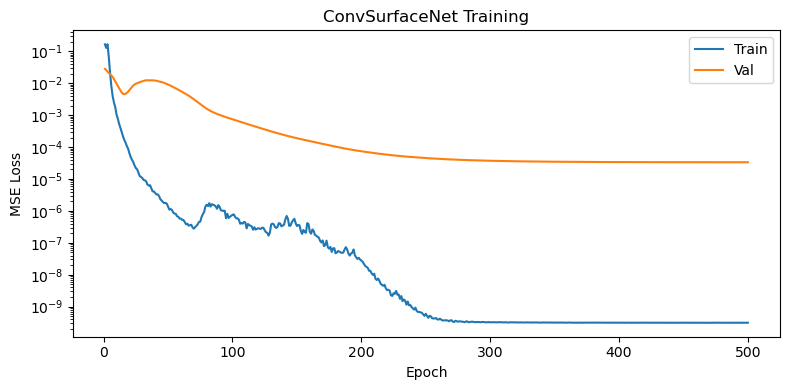

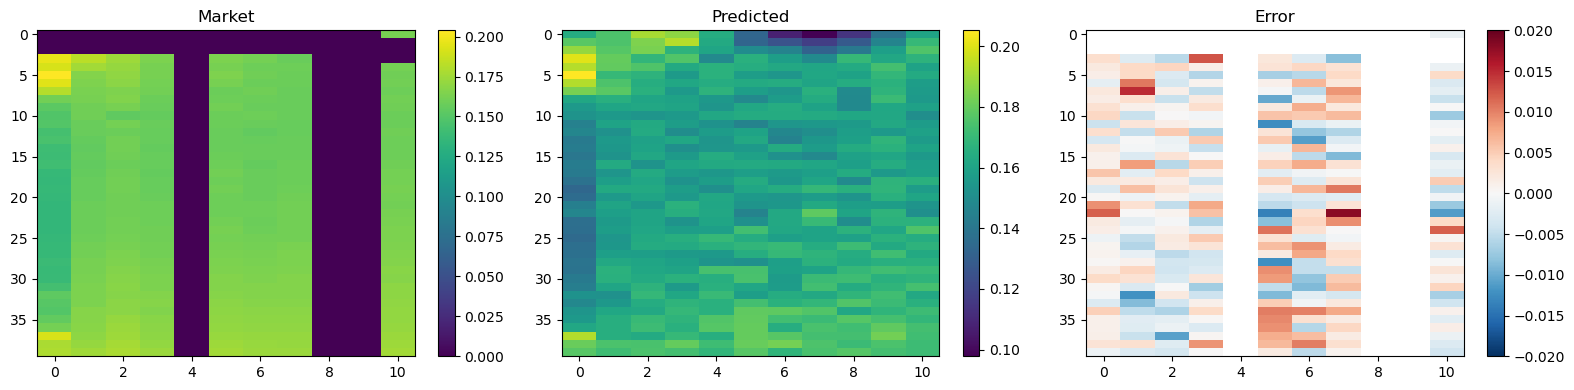


BENCHMARK COMPARISON
Model                           IV-MAPE (%)       RMSE
------------------------------------------------------------
Black-Scholes (flat vol)               8.32          —
Heston (stochastic vol)                5.83          —
NIG (infinite-activity)                8.22          —
VG (infinite-activity)                 8.37          —
BGM (infinite-activity)                8.35          —
ConvSurfaceNet (Gen 3 DL)              2.42     0.0050


In [2]:
# ============================================
# GENERATION 3: CONV2D SURFACE NETWORK
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from volsurf.pricing import black_scholes as bs

# ------------------------------------------------------------------
# Step 0: Ensure PyTorch is available
# ------------------------------------------------------------------
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
except ImportError:
    raise ImportError(
        "PyTorch not found. Install with:\n"
        "  conda install pytorch -c pytorch\n"
        "  or: pip install torch"
    )

from volsurf.models.gen3_dl import ConvSurfaceNet

# ------------------------------------------------------------------
# Prepare market data (assumes df from Notebook 1 is in scope)
# ------------------------------------------------------------------
# If running standalone, load df first:
df = pd.read_csv(os.path.join(DATA_DIR, "gld_benchmark_20250718.csv"))
# ... preprocessing from notebook 1 ...

TRADE_DATE = "2025-07-18"
GLD_SPOT = 308.3900
DIVIDEND_YIELD = 0.004


# ------------------------------------------------------------------
# Step 1: Pre-compute market implied volatilities
# ------------------------------------------------------------------
if "market_iv" not in df.columns:
    market_ivs = []
    for _, row in df.iterrows():
        try:
            iv = bs.implied_volatility(
                row["spot"], row["strike"], row["T"], row["risk_free_rate"],
                row["midPrice"], row.get("dividend_yield", DIVIDEND_YIELD),
                row["option_type"], bounds=(1e-6, 3.0),
            )
            market_ivs.append(iv)
        except Exception:
            market_ivs.append(np.nan)
    df["market_iv"] = market_ivs
    df = df.dropna(subset=["market_iv"]).copy()

r_avg = df["risk_free_rate"].mean()
q = DIVIDEND_YIELD

print("=" * 60)
print("GENERATION 3: CONV2D SURFACE NETWORK")
print("=" * 60)
print(f"Quotes with valid IV: {len(df)}")

# ------------------------------------------------------------------
# Step 2: Build regular grid from market data
# ------------------------------------------------------------------
n_strikes = 40
n_mats = df["T"].nunique()

model_dl = ConvSurfaceNet(grid_shape=(n_strikes, n_mats), smooth_lambda=1e-3)

iv_grid, mask_grid, k_centers, t_centers = model_dl.prepare_grid(
    df["strike"].values,
    df["T"].values,
    df["market_iv"].values,
    n_strike_bins=n_strikes,
    n_mat_bins=n_mats,
)

print(f"\nGrid shape: {iv_grid.shape}")
print(f"Observed cells: {int(mask_grid.sum())} / {mask_grid.size}")

# ------------------------------------------------------------------
# Step 3: Create train/val split
# ------------------------------------------------------------------
np.random.seed(42)
observed_indices = np.argwhere(mask_grid > 0)
n_val = int(0.2 * len(observed_indices))
val_idx = observed_indices[np.random.choice(len(observed_indices), n_val, replace=False)]

train_mask = mask_grid.copy()
val_mask = np.zeros_like(mask_grid)
for ki, ti in val_idx:
    train_mask[ki, ti] = 0
    val_mask[ki, ti] = 1

print(f"Train cells: {int(train_mask.sum())}  |  Val cells: {int(val_mask.sum())}")

# ------------------------------------------------------------------
# Step 4: Training
# ------------------------------------------------------------------
x = np.stack([iv_grid, train_mask], axis=0)
x_tensor = torch.from_numpy(x).unsqueeze(0).float()
target_tensor = torch.from_numpy(iv_grid).unsqueeze(0).unsqueeze(0).float()
train_mask_tensor = torch.from_numpy(train_mask).unsqueeze(0).unsqueeze(0).float()
val_mask_tensor = torch.from_numpy(val_mask).unsqueeze(0).unsqueeze(0).float()

optimizer = optim.Adam(model_dl.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500, eta_min=1e-5)

best_val_loss = float("inf")
best_state = None
patience = 50
patience_counter = 0

print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)

losses = []
for epoch in range(1, 501):
    model_dl.train()
    optimizer.zero_grad()
    pred = model_dl(x_tensor)
    loss_dict = model_dl.loss(pred, target_tensor, train_mask_tensor)
    loss_dict["total"].backward()
    optimizer.step()
    scheduler.step()

    model_dl.eval()
    with torch.no_grad():
        pred_val = model_dl(x_tensor)
        val_diff = (pred_val - target_tensor) * val_mask_tensor
        val_loss = (val_diff ** 2).sum() / (val_mask_tensor.sum() + 1e-8)

    losses.append({"epoch": epoch, "train": loss_dict["data"].item(), "val": val_loss.item()})

    if epoch <= 10 or epoch % 50 == 0:
        print(f"  Epoch {epoch:3d} | train={loss_dict['data'].item():.6f} | val={val_loss.item():.6f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = {k: v.cpu().clone() for k, v in model_dl.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n  Early stopping at epoch {epoch}")
            break

if best_state is not None:
    model_dl.load_state_dict(best_state)
    print(f"\nRestored best model (val loss = {best_val_loss:.6f})")

# ------------------------------------------------------------------
# Step 5: Evaluate
# ------------------------------------------------------------------
model_dl.eval()
with torch.no_grad():
    pred_full = model_dl(x_tensor).squeeze().cpu().numpy()

val_cells = val_mask > 0
if val_cells.sum() > 0:
    val_mape = np.mean(np.abs(pred_full[val_cells] - iv_grid[val_cells]) / iv_grid[val_cells]) * 100
    val_rmse = np.sqrt(np.mean((pred_full[val_cells] - iv_grid[val_cells]) ** 2))
    print(f"\nValidation IV-MAPE: {val_mape:.2f}%")
    print(f"Validation RMSE:    {val_rmse:.4f}")

all_obs = mask_grid > 0
full_mape = np.mean(np.abs(pred_full[all_obs] - iv_grid[all_obs]) / iv_grid[all_obs]) * 100
full_rmse = np.sqrt(np.mean((pred_full[all_obs] - iv_grid[all_obs]) ** 2))
print(f"Full obs IV-MAPE:   {full_mape:.2f}%")
print(f"Full obs RMSE:      {full_rmse:.4f}")

# ------------------------------------------------------------------
# Step 6: Plots
# ------------------------------------------------------------------
loss_df = pd.DataFrame(losses)
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(loss_df["epoch"], loss_df["train"], label="Train")
ax.semilogy(loss_df["epoch"], loss_df["val"], label="Val")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("ConvSurfaceNet Training"); ax.legend()
plt.tight_layout(); plt.savefig("gen3_convlstm_training.png", dpi=300, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
im0 = axes[0].imshow(iv_grid, aspect="auto", cmap="viridis"); axes[0].set_title("Market")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(pred_full, aspect="auto", cmap="viridis"); axes[1].set_title("Predicted")
plt.colorbar(im1, ax=axes[1])
err = pred_full - iv_grid; err[mask_grid == 0] = np.nan
im2 = axes[2].imshow(err, aspect="auto", cmap="RdBu_r", vmin=-0.02, vmax=0.02)
axes[2].set_title("Error"); plt.colorbar(im2, ax=axes[2])
plt.tight_layout(); plt.savefig("gen3_convlstm_surface.png", dpi=300, bbox_inches="tight"); plt.show()

# ------------------------------------------------------------------
# Step 7: Benchmark table
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("BENCHMARK COMPARISON")
print("=" * 60)
print(f"{'Model':<30} {'IV-MAPE (%)':>12} {'RMSE':>10}")
print("-" * 60)
print(f"{'Black-Scholes (flat vol)':<30} {'8.32':>12} {'—':>10}")
print(f"{'Heston (stochastic vol)':<30} {'5.83':>12} {'—':>10}")
print(f"{'NIG (infinite-activity)':<30} {'8.22':>12} {'—':>10}")
print(f"{'VG (infinite-activity)':<30} {'8.37':>12} {'—':>10}")
print(f"{'BGM (infinite-activity)':<30} {'8.35':>12} {'—':>10}")
print(f"{'ConvSurfaceNet (Gen 3 DL)':<30} {full_mape:>12.2f} {full_rmse:>10.4f}")

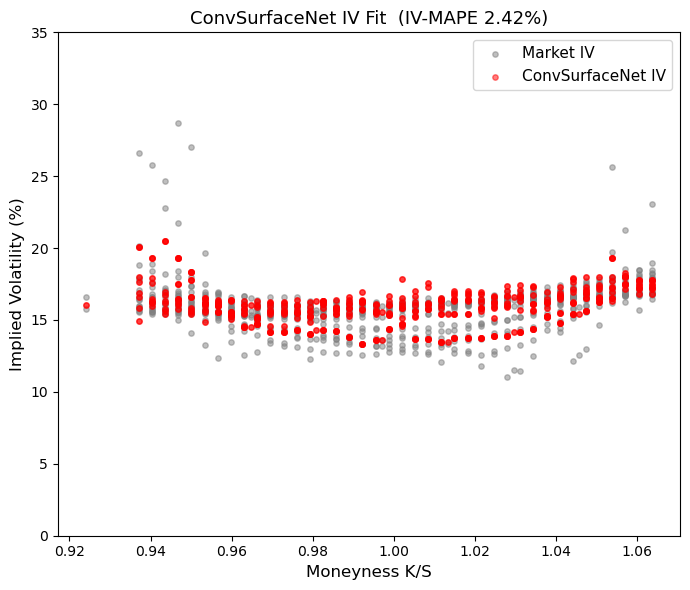

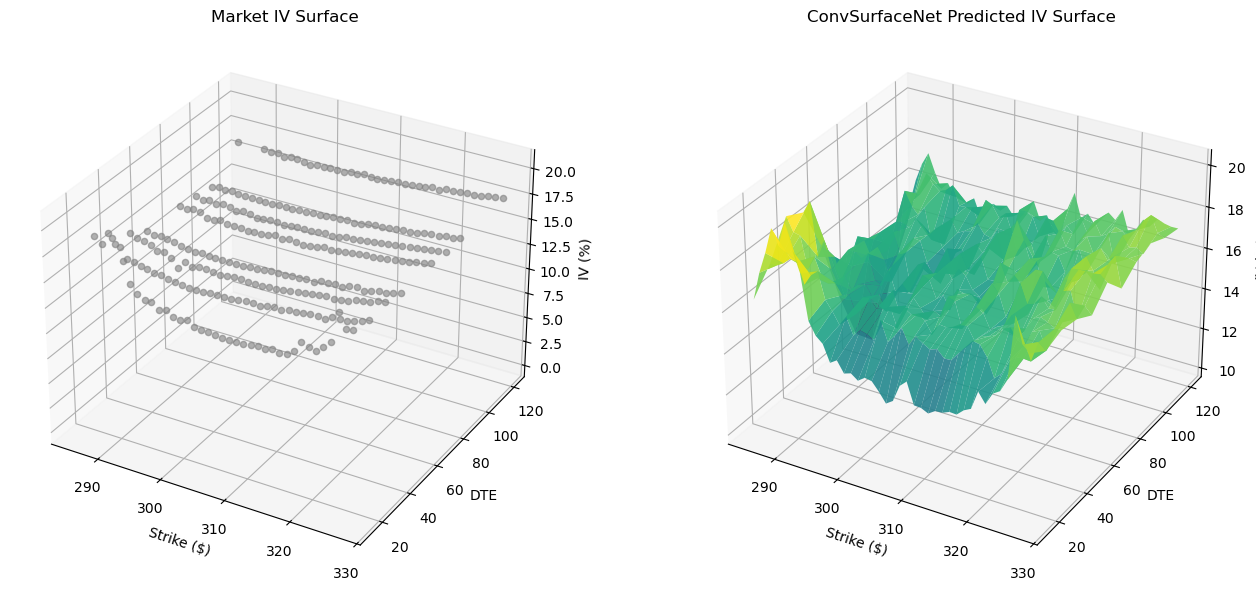

Saved: gen3_convlstm_iv_fit.png, gen3_convlstm_3d_surface.png


In [3]:
# ============================================
# GENERATION 3: ADDITIONAL PLOTS
# IV fit scatter + 3D surface
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from volsurf.pricing import black_scholes as bs

# ------------------------------------------------------------------
# Map grid predictions back to original quote positions
# ------------------------------------------------------------------

# For each quote, find its grid cell and get the predicted IV
pred_iv_per_quote = np.zeros(len(df))
for i, row in df.iterrows():
    # Find nearest grid cell
    k_diff = np.abs(k_centers - row["strike"])
    t_diff = np.abs(t_centers - row["T"])
    ki = np.argmin(k_diff)
    ti = np.argmin(t_diff)
    pred_iv_per_quote[i] = pred_full[ki, ti]

# Compute model IVs at original quote positions (invert BS on model prices)
# Actually we already have pred_iv_per_quote from the grid - that's the model IV

# ------------------------------------------------------------------
# Plot 1: IV Fit Scatter (model IV vs market IV)
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))
moneyness = df["strike"].values / GLD_SPOT

# Market IVs in gray, predicted in red
ax.scatter(moneyness, df["market_iv"].values * 100, c="gray", s=15, alpha=0.5, label="Market IV", zorder=1)
ax.scatter(moneyness, pred_iv_per_quote * 100, c="red", s=15, alpha=0.5, label="ConvSurfaceNet IV", zorder=2)

ax.set_xlabel("Moneyness K/S", fontsize=12)
ax.set_ylabel("Implied Volatility (%)", fontsize=12)
ax.set_title(f"ConvSurfaceNet IV Fit  (IV-MAPE {full_mape:.2f}%)", fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, max(35, np.max(df["market_iv"]) * 110))

plt.tight_layout()
plt.savefig("gen3_convlstm_iv_fit.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# Plot 2: 3D IV Surface (predicted)
# ------------------------------------------------------------------

fig = plt.figure(figsize=(14, 6))

# 3D Market Surface
ax1 = fig.add_subplot(121, projection='3d')
K_grid, T_grid = np.meshgrid(k_centers, t_centers, indexing='ij')
surf1 = ax1.plot_surface(K_grid, T_grid * 365, df["market_iv"].max() * np.ones_like(K_grid), 
                          alpha=0.0)  # placeholder for axis scaling
# Plot actual market data as scatter
for i in range(len(k_centers)):
    for j in range(len(t_centers)):
        if mask_grid[i, j] > 0:
            ax1.scatter(k_centers[i], t_centers[j] * 365, iv_grid[i, j] * 100,
                       c='gray', s=20, alpha=0.6)

ax1.set_xlabel("Strike ($)")
ax1.set_ylabel("DTE")
ax1.set_zlabel("IV (%)")
ax1.set_title("Market IV Surface")

# 3D Predicted Surface
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(K_grid, T_grid * 365, pred_full * 100,
                         cmap='viridis', edgecolor='none', alpha=0.9)
ax2.set_xlabel("Strike ($)")
ax2.set_ylabel("DTE")
ax2.set_zlabel("IV (%)")
ax2.set_title("ConvSurfaceNet Predicted IV Surface")

plt.tight_layout()
plt.savefig("gen3_convlstm_3d_surface.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: gen3_convlstm_iv_fit.png, gen3_convlstm_3d_surface.png")